**lag 추가 binary 삭제**

In [22]:
import pandas as pd
import numpy as np
from sklearn.model_selection import KFold
from sklearn.metrics import mean_absolute_error
import lightgbm as lgb

In [42]:
# layout 상관계수만확인 하고 삭
train = train.merge(layout, on='layout_id', how='left')

# layout 수치 피처 전체 상관계수
layout_num_cols = [
    'aisle_width_avg', 'intersection_count', 'one_way_ratio',
    'pack_station_count', 'charger_count', 'layout_compactness',
    'zone_dispersion', 'robot_total', 'building_age_years',
    'floor_area_sqm', 'ceiling_height_m', 'fire_sprinkler_count',
    'emergency_exit_count'
]

corr = train[layout_num_cols].corrwith(train[target]).sort_values(key=abs, ascending=False)
print("=== layout 피처 vs 타겟 상관계수 (절댓값 내림차순) ===")
for feat, r in corr.items():
    bar = '█' * int(abs(r) * 100)
    print(f"  {feat:25s}: {r:+.4f}  {bar}")


=== layout 피처 vs 타겟 상관계수 (절댓값 내림차순) ===
  pack_station_count       : -0.1862  ██████████████████
  robot_total              : -0.1105  ███████████
  emergency_exit_count     : -0.0443  ████
  zone_dispersion          : -0.0267  ██
  layout_compactness       : -0.0220  ██
  one_way_ratio            : -0.0186  █
  intersection_count       : -0.0165  █
  building_age_years       : -0.0137  █
  charger_count            : -0.0128  █
  fire_sprinkler_count     : +0.0098  
  ceiling_height_m         : +0.0064  
  floor_area_sqm           : +0.0056  
  aisle_width_avg          : -0.0028  


In [65]:
train = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/smart_factory/data/raw/train.csv')
test = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/smart_factory/data/raw/test.csv')
layout = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/smart_factory/data/raw/layout_info.csv')


target = 'avg_delay_minutes_next_30m'
drop_cols = ['ID', 'scenario_id', target, 'layout_id']

print(f'train: {train.shape}, test: {test.shape}, layout: {layout.shape}')

train: (250000, 94), test: (50000, 93), layout: (300, 15)


In [66]:
train = train.sort_values(['scenario_id', 'ID']).reset_index(drop=True)
test  = test.sort_values(['scenario_id', 'ID']).reset_index(drop=True)


In [67]:
# ── timeslot 추가 ─────────────────────────────────────────
# 시나리오 내 슬롯 순서 (0~24)
# EDA에서 슬롯 0=11.3분 → 슬롯 24=21.9분으로 누적 증가 확인
train['timeslot'] = train.groupby('scenario_id').cumcount()
test['timeslot']  = test.groupby('scenario_id').cumcount()

In [68]:
lag_cols = [
    'battery_mean',
    'low_battery_ratio',
    'order_inflow_15m',
    'robot_utilization',
    'robot_charging',
    'congestion_score',
]

for col in lag_cols:
    if col not in train.columns:
        continue
    # lag1: 직전 슬롯 값
    train[f'{col}_lag1'] = train.groupby('scenario_id')[col].shift(1)
    test[f'{col}_lag1']  = test.groupby('scenario_id')[col].shift(1)

    # diff1: 직전 슬롯 대비 변화량 (소모 속도)
    # battery_diff1이 음수 = 배터리 소모 중
    # order_diff1이 양수  = 주문 증가 중
    train[f'{col}_diff1'] = train[col] - train[f'{col}_lag1']
    test[f'{col}_diff1']  = test[col]  - test[f'{col}_lag1']

print(f'추가된 피처 수: {len(lag_cols) * 2}개')  # lag1 + diff1
print(f'전체 피처 수: {len(train.drop(columns=["ID","scenario_id",target,"layout_id"]).columns)}개')


추가된 피처 수: 12개
전체 피처 수: 103개


In [69]:
#layout 상관관계에 따라서
layout_use = layout[['layout_id', 'layout_type',
                      'pack_station_count', 'robot_total',
                      'charger_count']].copy()

# 파생 피처 상관계수 자체가 무의미  비율로 실제 병목 표현
layout_use['charger_per_robot'] = (
    layout_use['charger_count'] / layout_use['robot_total']
)
layout_use['robot_per_station'] = (
    layout_use['robot_total'] / layout_use['pack_station_count']
)

# binary 순서로 처리하면 각 차이 못내니깐
layout_use['is_hub_spoke'] = (layout_use['layout_type'] == 'hub_spoke').astype(int)
layout_use['is_narrow']    = (layout_use['layout_type'] == 'narrow').astype(int)

# merge에 필요 없는 컬럼 제거
layout_use = layout_use.drop(columns=['layout_type', 'charger_count'])

# merge
train = train.merge(layout_use, on='layout_id', how='left')
test  = test.merge(layout_use,  on='layout_id', how='left')

layout_added = [c for c in layout_use.columns if c != 'layout_id']
print(f'layout 추가 피처: {layout_added}')

print(f'전체 피처 수: {len(train.drop(columns=["ID","scenario_id",target,"layout_id"]).columns)}개')
print(f'결측 확인: {train[layout_added].isnull().sum().sum()}')  # 0이어야 함

layout 추가 피처: ['pack_station_count', 'robot_total', 'charger_per_robot', 'robot_per_station', 'is_hub_spoke', 'is_narrow']
전체 피처 수: 109개
결측 확인: 0


In [70]:
X      = train.drop(columns=drop_cols).fillna(-999)
y      = train[target]
X_test = test.drop(columns=['ID', 'scenario_id', 'layout_id']).fillna(-999)
groups = train['scenario_id']

In [71]:
print(f'피처 수: {X.shape[1]}')
print(f'timeslot 포함 확인: {"timeslot" in X.columns}')
print(f'결측 수: {X.isnull().sum().sum()}')  # 0이어야 함


피처 수: 109
timeslot 포함 확인: True
결측 수: 0


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.176035 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 22862
[LightGBM] [Info] Number of data points in the train set: 200000, number of used features: 109
[LightGBM] [Info] Start training from score 9.016370
[200]	valid_0's l1: 9.39861
Fold 1 | Train MAE: 8.3424 | Val MAE: 9.3715 | Gap: 1.0291 | best iter: 343
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.261264 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 22858
[LightGBM] [Info] Number of data points in the train set: 200000, number of used features: 109
[LightGBM] [Info] Start training from score 9.021746
Fold 2 | Train MAE: 8.7978 | Val MAE: 9.1095 | Gap: 0.3117 | best iter: 139
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the over

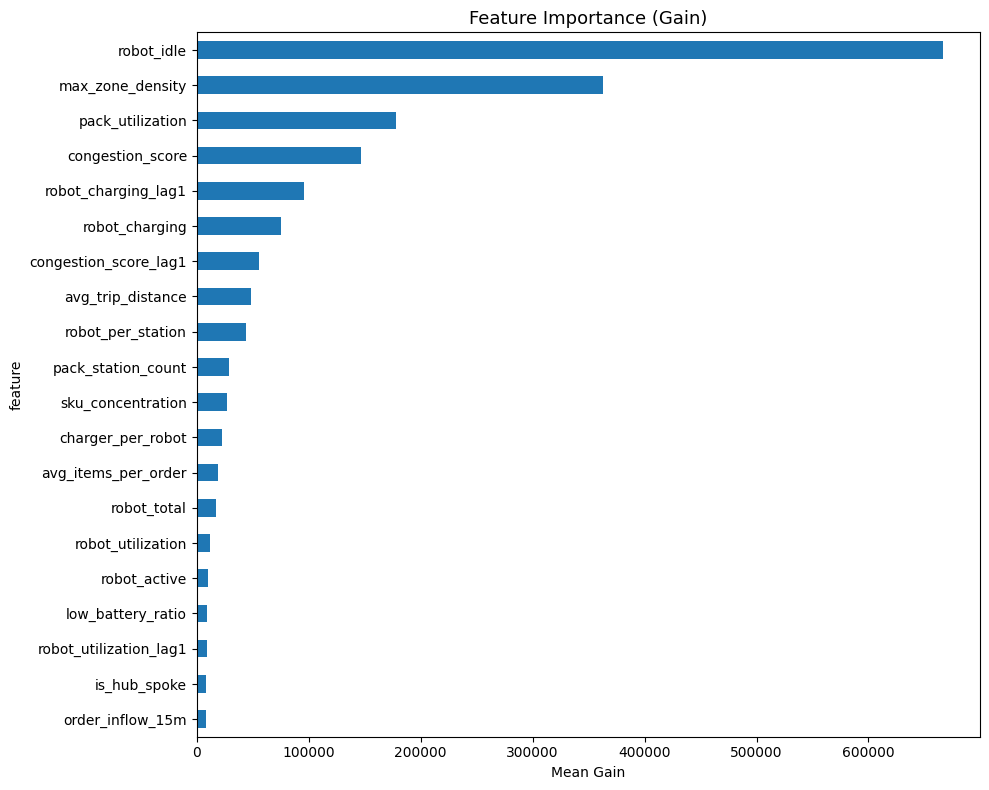

In [74]:
from sklearn.model_selection import GroupKFold
import matplotlib.pyplot as plt

# ── 5-Fold GroupKFold ─────────────────────────────────────
gkf = GroupKFold(n_splits=5)
oof_pred = np.zeros(len(X))
test_pred = np.zeros(len(X_test))

train_mae_scores = []
mae_scores = []
feature_importances = pd.DataFrame()

for fold, (tr_idx, val_idx) in enumerate(gkf.split(X, y, groups)):
    X_tr, X_val = X.iloc[tr_idx], X.iloc[val_idx]
    y_tr, y_val = y.iloc[tr_idx], y.iloc[val_idx]

    model = lgb.LGBMRegressor(
        objective='mae',
        metric='mae',
        n_estimators=1000,
        learning_rate=0.05,
        num_leaves=31,
        random_state=42,
        n_jobs=-1
    )

    model.fit(
        X_tr, y_tr,
        eval_set=[(X_val, y_val)],
        callbacks=[
            lgb.early_stopping(50, verbose=False),
            lgb.log_evaluation(200)
        ]
    )

    # ✅ Train MAE 추가
    train_pred = model.predict(X_tr)
    train_mae  = mean_absolute_error(y_tr, train_pred)
    train_mae_scores.append(train_mae)

    oof_pred[val_idx] = model.predict(X_val)
    test_pred += model.predict(X_test) / 5

    fold_mae = mean_absolute_error(y_val, oof_pred[val_idx])
    mae_scores.append(fold_mae)

    # gain 중요도로 기록
    imp = pd.DataFrame({
        'feature': X.columns,
        'gain': model.booster_.feature_importance(importance_type='gain'),
        'split': model.booster_.feature_importance(importance_type='split'),
        'fold': fold + 1
    })
    feature_importances = pd.concat([feature_importances, imp], axis=0)

    print(f'Fold {fold+1} | Train MAE: {train_mae:.4f} | Val MAE: {fold_mae:.4f} | Gap: {fold_mae - train_mae:.4f} | best iter: {model.best_iteration_}')

oof_mae = mean_absolute_error(y, oof_pred)
print(f'\n✅ 각 Fold Train MAE : {[round(m, 4) for m in train_mae_scores]}')
print(f'✅ 각 Fold Val MAE   : {[round(m, 4) for m in mae_scores]}')
print(f'✅ 평균 Train MAE    : {np.mean(train_mae_scores):.4f}')
print(f'✅ 평균 Val MAE      : {np.mean(mae_scores):.4f}')
print(f'✅ 평균 Gap          : {np.mean(mae_scores) - np.mean(train_mae_scores):.4f}')
print(f'✅ Val MAE 표준편차  : {np.std(mae_scores):.4f}')
print(f'✅ OOF MAE           : {oof_mae:.4f}')

# ── 피처 중요도 (gain 기준) ───────────────────────────────
imp_mean = (
    feature_importances
    .groupby('feature')[['gain', 'split']]
    .mean()
    .sort_values('gain', ascending=False)
    .head(20)
)

print('\n✅ 상위 20개 피처 중요도 (gain 기준)')
print(imp_mean.round(1))

fig, ax = plt.subplots(figsize=(10, 8))
imp_mean['gain'].sort_values().plot.barh(ax=ax)
ax.set_title('Feature Importance (Gain)', fontsize=13)
ax.set_xlabel('Mean Gain')
plt.tight_layout()
plt.show()

# 제출용 예측값 후처리
test_pred = np.clip(test_pred, 0, None)

In [76]:
test['prediction'] = test_pred

submission = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/smart_factory/sample_submission.csv')[['ID']]
submission = submission.merge(
    test[['ID', 'prediction']],
    on='ID',
    how='left'
)
submission = submission.rename(columns={'prediction': target})
submission.to_csv('baseline_v61_addlayout.csv', index=False)

print(f'예측값 범위: {submission[target].min():.2f} ~ {submission[target].max():.2f}')
print(f'NaN 수: {submission[target].isnull().sum()}')

예측값 범위: 0.00 ~ 45.54
NaN 수: 0
